In [ ]:
# Third-party numerical libraries
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import arviz as az

# Bayesian inference framework
import bayesbay
from bayesbay.discretization import Voronoi1D
from bayesbay.likelihood import Target, LogLikelihood
from bayesbay.parameterization import ParameterSpace, Parameterization
from bayesbay.prior import UniformPrior

# Notebook interface
import marimo as mo

#Educator notebook: From Polynomials to Change-Point Models - Curve Fitting with CoFI

## Introduction

This tutorial demonstrates how CoFI (Common Framework for Inference) empowers educators and learners to rapidly explore inference concepts that would otherwise require substantial implementation effort. Rather than spending time writing boilerplate code for each new method, users can focus on the science: understanding when models succeed, when they fail, and how to improve them.

### Why CoFI for Education?

Implementing curve fitting from scratch—handling optimisation, uncertainty quantification, and model comparison—demands significant technical overhead. Extending to more sophisticated approaches like change-point detection multiplies this complexity. CoFI removes these barriers by providing:

- **A unified interface** across inference methods, so learners invest time in understanding concepts rather than debugging implementations
- **Rapid experimentation**, allowing students to test hypotheses about model suitability within minutes
- **Seamless method switching**, making it straightforward to progress from simple to complex models as understanding deepens

This design philosophy is particularly valuable in educational settings, where the goal is conceptual clarity rather than focusing on low-level implementation details.

### Tutorial Overview

The tutorial follows a progression of increasing sophistication in approach to allow the student to build their understanding gradually:

1. **Polynomial Fitting Fundamentals** — CoFI's problem-definition interface is introduced through polynomial regression, establishing the core workflow: define a `BaseProblem`, select `InversionOptions`, and run an `Inversion`.

2. **Application to Sea Level Data** — The polynomial model is applied to historical sea level observations, grounding abstract concepts in a real dataset of relevance.

3. **Model Evaluation and Limitations** — Examining the polynomial fit reveals systematic residuals. A single polynomial cannot adequately capture this behaviour. This is a teaching moment: recognising model inadequacy from residual patterns.

4. **Transitioning to a Change-Point Model** — Motivated by the data, a change-point regression model permits different rates of change before and after a transition point/time. With CoFI, this conceptually significant model change requires only minimal code modifications—no new library, no rewritten optimisation loop.

### Key Takeaway

This tutorial showcases how CoFI lowers the barrier to exploring sophisticated inference techniques. By maintaining a consistent API, CoFI lets learners ask the question that matters—*which model best describes my data?*—and answer it immediately through experimentation, rather than getting lost in implementation complexity.

## Polynomial curves

### Introduction

The regression model consists of polynomial curves,

$$y(x) = \sum_{j=0}^M m_j x^j\,$$

where $m_j, (j=0,\dots M)$ are the 'model coefficients' to be constrained by the data. Here, $M$ is the order of the polynomial: For $M=0$ the model is a single constant (fixed y) level and hence 1 unknown parameter, $m_o$. With  $M=1$ there is a straight line with 2 parameters, if $M=2$ it is a quadratic with 3 parameters, and so on.

For the case of $N$ data and order $M=3$ polynomial the data/model relationship takes the  form:

$$\left(\begin{array}{c}y_0\\y_1\\\vdots\\y_N\end{array}\right) = \left(\begin{array}{ccc}1&x_0&x_0^2&x_0^3\\1&x_1&x_1^2&x_1^3\\\vdots&\vdots&\vdots\\1&x_N&x_N^2&x_N^3\end{array}\right)\left(\begin{array}{c}m_0\\m_1\\m_2\\m_3\end{array}\right)$$


This clearly has the required general form, $\mathbf{d} =G{\mathbf m}$.

where:

- $\textbf{d}$ is the vector of data values, ($y_0,y_1,\dots,y_N$);
- $\textbf{m}$ is the vector of model parameters, ($m_0,m_1,m_2, m_3$);
- $G$ is the  basis  (or design) matrix of this linear regression problem (sometimes called the ***Jacobian*** matrix).

The following Python functions compute $G$ and the model prediction.

In [ ]:
np.random.seed(42)
m_true = np.array([-6,-5,2,1])                              # m
N = 20                                                      # N
sigma = 1.0                                                 # sigma
x_obs = np.random.choice(np.linspace(-3.5,2.5), size=N)

In [ ]:
def jacobian(x=x_obs,m=m_true):
    return np.array([x**i for i in range(len(m))]).T

def forward(m,x):
    return jacobian(x,m).dot(m)

Using these functions, a set of noisy observations $y_i (i=0,\dots,N)$ can be generated for known locations $x_i (i=0,\dots,N)$ using a known function: $y=-6-5x+2x^2+x^3$, with Gaussian random noise ${\cal N}(0,\sigma^2)$ added, where $\sigma=1.0$.

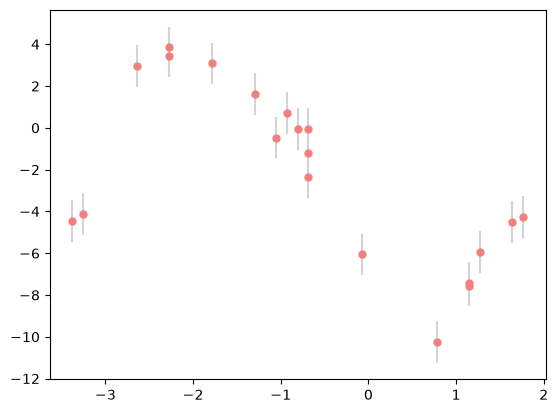

In [ ]:
y_obs = forward(m_true,x_obs) + np.random.normal(0,sigma,len(x_obs))  # d

def plot_data():
    fig, ax = plt.subplots()
    ax.errorbar(x_obs, y_obs, yerr=sigma,fmt='.',color="lightcoral",ecolor='lightgrey',ms=10)
    return ax

plot_data()

### Fitting a polynomial - Linear approach

For a polynomial, the forward model is linear in the coefficients, $m_j, (j=0,\dots M)$ thus the model parameter can be estimated by solving a least squares problem. In the example here $N>M$ and the data are linearly independent and so the system becomes over-determined

For $\mathbf{d} = \mathbf{G}\mathbf{m}$, the least squares solution is:

$$\hat{\mathbf{m}} = (\mathbf{G}^T \mathbf{G})^{-1} \mathbf{G}^T \mathbf{d}$$

Typically though data are noisy and thus they should be weighted by the data covariance matrix.

$$\hat{\mathbf{m}} = (\mathbf{G}^T \mathbf{C}_d^{-1} \mathbf{G})^{-1} \mathbf{G}^T \mathbf{C}_d^{-1} \mathbf{d}$$

For independent identically distribution Gaussian noise, the inverse data covariance matrix is defined as $\mathbf{C}_d^{-1} = \frac{1}{\sigma^2} \mathbf{I}$, where $\sigma = 1.0$ matches the standard deviation of the Gaussian noise added to the synthetic data. The reader will verify that for this special case the two solutions above are identical.

In [ ]:
def Cd_inv(sigma=sigma, obs_n=len(x_obs)):
    return 1/sigma**2 * np.identity(obs_n)

Inverse problems in CoFI are organised around three classes  `BaseProblem`, `InversionOptions`, and `Inversion`.

- `BaseProblem` provides information about what is to be solved. It defines the functions that inverse methods provided by CoFI require to solve the inverse problem. Parameter estimation methods, for example, almost always require an objective function.

- `InversionOptions` provides information about how to solve the inverse problem. It defines the solving method and/or backend tool, along with any solver-specific parameters.

- `Inversion` can be seen as an inversion engine that takes in the above two as information, and will produce an `InversionResult` upon running.

These are imported from CoFI below.

In [ ]:
from cofi import BaseProblem, InversionOptions, Inversion

When the forward problem was introduced to generate synthetic data, the functions needed to set up the `BaseProblem` for polynomial fitting were defined.

In [ ]:
inv_problem = BaseProblem()
inv_problem.set_data(y_obs)
inv_problem.set_forward(forward, args=(x_obs,))
inv_problem.set_jacobian(jacobian())
inv_problem.set_data_covariance_inv(Cd_inv())

CoFI groups solving methods for inverse problems into `matrix solvers`, `optimization` and `sampling` methods. The polynomial fitting has been formulated as a linear problem, so the `matrix solvers` group is appropriate. Once the group has been chosen, CoFI can provide a list of backends tools to solve the problem.

In [ ]:
inv_options = InversionOptions()
inv_options.suggest_solving_methods()
inv_options.set_solving_method('matrix solvers')
inv_options.suggest_tools()

The following solving methods are supported:
{'matrix solvers', 'sampling', 'optimization'}

Use `suggest_tools()` to see a full list of backend tools for each method
Based on the solving method you've set, the following tools are suggested:
['scipy.linalg.lstsq', 'cofi.simple_newton', 'scipy.sparse.linalg']

Use `InversionOptions.set_tool(tool_name)` to set a specific tool from above
Use `InversionOptions.set_solving_method(method_name)` to change solving method
Use `InversionOptions.unset_solving_method()` if you'd like to see more options
Check CoFI documentation 'Advanced Usage' section for how to plug in your own tool or solver


While the user may now choose on a particular solving method, this can be skipped as CoFI provides good defaults that work for most problems. For matrix solvers, the default backend tool is `scipy.linalg.lstsq`. The `InversionOptions` object provides a summary of how the inverse problem will be solved.

In [ ]:
inv_options.summary()

Summary for inversion options
Solving method: matrix solvers
Use `suggest_solving_methods()` to check available solving methods.
-----------------------------
Backend tool: `<class 'cofi.tools._scipy_lstsq.ScipyLstSq'> (by default)` - SciPy's wrapper function over LAPACK's linear least-squares solver, using 'gelsd', 'gelsy' (default), or 'gelss' as backend driver
References: ['https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html', 'https://www.netlib.org/lapack/lug/node27.html']
Use `suggest_tools()` to check available backend tools.
-----------------------------
Solver-specific parameters: None set
Use `suggest_solver_params()` to check required/optional solver-specific parameters.


With `BaseProblem` and `InversionOptions` defined, an inversion can be run by combing them in the `Inversion` object.

In [ ]:
_inversion = Inversion(inv_problem, inv_options)
result_lstsq = _inversion.run()

Different inversion algorithms return different types of information about the inversion result and CoFI gathers this information.

In [ ]:
print(f"The inversion result from `scipy.linalg.lstsq`: {result_lstsq.model}\n")
result_lstsq.summary()

The inversion result from `scipy.linalg.lstsq`: [-5.71964359 -5.10903808  1.82553662  0.97472374]

Summary for inversion result
SUCCESS
----------------------------
model: [-5.71964359 -5.10903808  1.82553662  0.97472374]
sum_of_squared_residuals: []
effective_rank: 4
singular_values: [3765.51775745   69.19268194   16.27124488    3.85437889]
model_covariance: [[ 0.19027447  0.05812534 -0.08168411 -0.02550866]
 [ 0.05812534  0.08673796 -0.03312809 -0.01812686]
 [-0.08168411 -0.03312809  0.05184851  0.01704165]
 [-0.02550866 -0.01812686  0.01704165  0.00676031]]


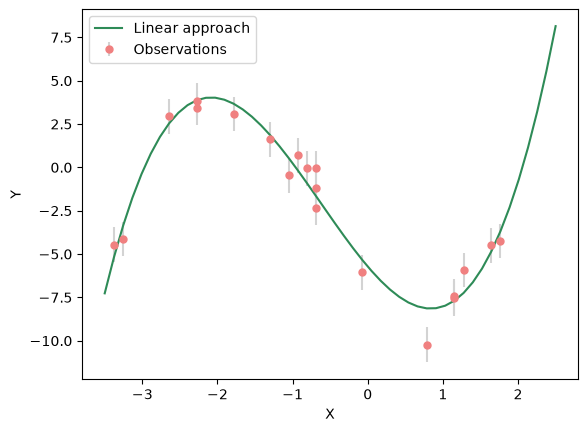

In [ ]:
x = np.linspace(-3.5, 2.5)

def plot_linear_fit():
    fig, ax = plt.subplots()
    ax.errorbar(x_obs, y_obs, yerr=sigma, fmt='.', color="lightcoral", ecolor='lightgrey', ms=10, label="Observations")
    ax.plot(x, jacobian(x).dot(result_lstsq.model), color="seagreen", label="Linear approach")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    return ax

plot_linear_fit()

### Fitting a polynomial - Iterative optimiser approach

The over-determined linear problem, $\mathbf{d} = G\mathbf{m}$, with Gaussian data noise can also be solved by minimising the squares of the residuals of the linear equations, $\Delta \mathbf{d}^T \mathbf{C}_d^{-1} \Delta \mathbf{d}$ where $\Delta \mathbf{d} = \mathbf{d} - G \mathbf{m}$. This involves solving for an update of the model parameter $\Delta \mathbf{m}$ such that:

$$\mathbf{m}_{k+1} = \mathbf{m}_k + \Delta \mathbf{m}$$

The gradient of the misfit function with respect to the model parameters is:

$$\nabla_\mathbf{m} \phi = -G^T \mathbf{C}_d^{-1} \Delta \mathbf{d}$$

Setting this to zero and solving yields the iterative update. For a steepest descent approach:

$$\Delta \mathbf{m} = \alpha G^T \mathbf{C}_d^{-1} \Delta \mathbf{d}$$

where $\alpha$ is a step length parameter which must be chosen at each iteration. This type of iterative approach is particularly useful when the number of unknowns is large and direct matrix inversion approach used earlier is impractical. It also extends naturally to non-linear problems where the Jacobian matrix, $G$, is a function of the model parameters $\mathbf{m}$ and must be re-evaluated iteratively as the current model estimate is updated.

Alternatively, if matrix inversion is practical, then a Gauss-Newton approach could be used and the update becomes:

$$\Delta \mathbf{m} = (G^T \mathbf{C}_d^{-1} G)^{-1} G^T \mathbf{C}_d^{-1} \Delta \mathbf{d}$$



Iterative approaches require a starting model or initial guess at the model parameters $\mathbf{m}$. This needs to be added to the `BaseProblem`. Note that there is no need to create a new `BaseProblem`—the existing one can be updated.

In [ ]:
inv_problem.set_initial_model(np.ones(4))
inv_problem.set_data_misfit("squared error")

The existing `InversionOptions` can also be reused by simply changing the solving method and tool.

In [ ]:
inv_options.set_solving_method('optimization')
inv_options.set_tool("scipy.optimize.minimize")
inv_options.hyper_params.clear()
inv_options.set_params(method="Nelder-Mead")

Using the updated `BaseProblem` and `InversionOptions`, a new inversion can be created and run.

In [ ]:
######## CoFI Inversion - run it
_inversion = Inversion(inv_problem, inv_options)
result_optimize = _inversion.run()

######## CoFI InversionResult - check result
print(f"The inversion result from `scipy.optimize.minimize`: {result_optimize.model}\n")
result_optimize.summary()

The inversion result from `scipy.optimize.minimize`: [-5.71967431 -5.10913992  1.82556456  0.9747426 ]

Summary for inversion result
SUCCESS
----------------------------
fun: 14.961508008942804
nit: 193
nfev: 330
status: 0
message: Optimization terminated successfully.
final_simplex: (array([[-5.71967431, -5.10913992,  1.82556456,  0.9747426 ],
       [-5.71958302, -5.10907158,  1.8255083 ,  0.97472628],
       [-5.71969118, -5.10911404,  1.82556388,  0.97474474],
       [-5.7197282 , -5.10917942,  1.82554925,  0.97474097],
       [-5.71960767, -5.10913354,  1.82551338,  0.97473478]]), array([14.96150801, 14.96150804, 14.96150805, 14.9615082 , 14.96150821]))
model: [-5.71967431 -5.10913992  1.82556456  0.9747426 ]


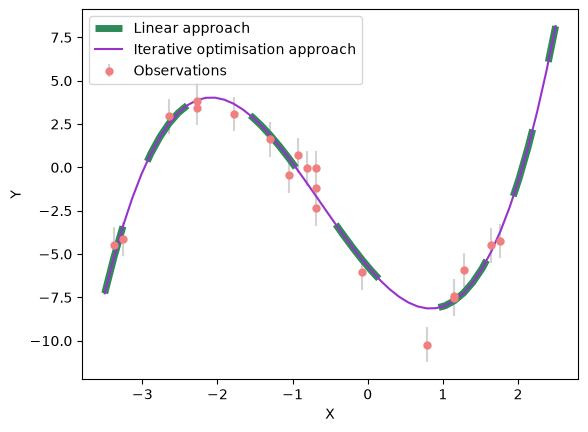

In [ ]:
def plot_comparison():
    fig, ax = plt.subplots()
    ax.errorbar(x_obs, y_obs, yerr=sigma, fmt='.', color="lightcoral", ecolor='lightgrey', ms=10, label="Observations")
    ax.plot(x, jacobian(x).dot(result_lstsq.model), color="seagreen", label="Linear approach",linestyle="--",dashes=(10, 10),lw=5)
    ax.plot(x, jacobian(x).dot(result_optimize.model), color="darkorchid", label="Iterative optimisation approach")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    return ax
plot_comparison()

We can see then that the two approaches produce identical polynomial curves.

### Fitting a polynomial - Bayesian approach

Instead of finding a single best-fitting model, a Bayesian approach seeks the distribution of models that represent a compromise between fitting the data and being consistent with our prior beliefs. Here we seek to find $p(\mathbf{m}|\mathbf{d}_{obs})$, which is often called the ${a ~posteriori}$  probability density function (PDF) and represents the information we have on the model, $\mathbf{m}$, given the observed data, $\mathbf{d}_{obs}$. Bayes' theorem states that this distribution is given by

$$p(\mathbf{m}|\mathbf{d}_{obs}) = K p(\mathbf{d}_{obs}|\mathbf{m})p(\mathbf{m})$$

where $p(\mathbf{m})$ is the ${a ~priori}$ or prior PDF, representing knowledge on $\mathbf{m}$ before considering the data; $p(\mathbf{d}_{obs}|\mathbf{m})$ is the Likelihood function, measuring how probable the data would be given any model, $\mathbf{m}$; and $K$ is some normalizing constant.

Usually direct examination of the posterior probability density function is only possible in simple cases and the practical goal is to draw random samples from $p(\mathbf{m}|\mathbf{d}_{obs})$ over model space and make inferences from the resulting ensemble of models.

#### Likelihood function

Data errors follow a Gaussian in this example, so a Likelihood function $p({\mathbf d}_{obs}| {\mathbf m})$ can be defined as follows.

$$
p({\mathbf d}_{obs} | {\mathbf m}) \propto \exp \left\{- \frac{1}{2} ({\mathbf d}_{obs}-{\mathbf d}_{pred}({\mathbf m}))^T C_D^{-1} ({\mathbf d}_{obs}-{\mathbf d}_{pred}({\mathbf m})) \right\}
$$

where ${\mathbf d}_{obs}$ represents the observed y values and ${\mathbf d}_{pred}({\mathbf m})$ are those predicted by the polynomial model $({\mathbf m})$.  In practice, only the log of the Likelihood needs to be evaluated, $\log p({\mathbf d}_{obs} | {\mathbf m})$.

In [ ]:
def log_likelihood(model):
    y_pred = forward(model, x_obs)
    residual = y_obs - y_pred
    return -0.5 * residual @  Cd_inv() @ residual

#### Prior distribution

Bayesian sampling requires a prior probability density function, and it is not always obvious what the prior should be. Here a uniform prior within specified bounds is used.

$$
\begin{align}
p({\mathbf m}) &= \frac{1}{V},\quad  l_j \le m_j \le u_j, \quad (i=0,\dots,M)\\
         &= 0, \quad {\rm otherwise},
\end{align}
$$

where $l_j$ and $u_j$ are lower and upper bounds on the model coefficient, $m_j$ and V is the normalization constant for the prior PDF and equal to volume of the feasible model space

$$
V = \prod_{j=0}^M (u_j-l_j).
$$

If the order of the polynomial is fixed, then $V$ can be absorbed into the constnat $K$ in Bayes' theorem and ignored. In the examples below the uniform prior distribution is used with ${\mathbf l}^T = (-10.,-10.,-10.,-10.)$, and ${\mathbf u}^T = (10.,10.,10.,10.)$.

In [ ]:
m_lower_bound = np.ones(4) * (-10.)             # lower bound for uniform prior
m_upper_bound = np.ones(4) * 10                 # upper bound for uniform prior

def log_prior(model):    # uniform distribution
    for i in range(len(m_lower_bound)):
        if model[i] < m_lower_bound[i] or model[i] > m_upper_bound[i]: return -np.inf
    return 0.0 # model lies within bounds -> return log(1)

#### The Affine Invariant Markov chain Monte Carlo (MCMC) Ensemble sampler

Where possible, CoFI builds on existing approaches and makes them available through a common interface. This example uses *The Affine Invariant Markov chain Monte Carlo (MCMC) Ensemble sampler*
[Goodman and Weare 2010](https://msp.org/camcos/2010/5-1/p04.xhtml) to sample the
posterior distribution of the model. By default CoFI uses the implementation in the package [emcee](https://emcee.readthedocs.io/en/stable/).

An advantage of this package is that only a small set of hyperparameters needs to be defined (e.g. the number of walkers, steps, and starting location). $emcee$ has useful defaults for all others which can be changed if desired. See the docs for details [emcee](https://emcee.readthedocs.io/en/stable/).

All walkers start in a small hypersphere around a chosen point $(0, 0, 0, 0)$. Alternatively, any sample of the prior distribution may be chosen, or to improve convergence, a solution found through some preliminary minimization of the negative log-Likelihood.

In [ ]:
nwalkers_emcee = 32
ndim = 4
nsteps = 10_000
walkers_start_emcee = np.zeros(ndim) + 1e-4 * np.random.randn(nwalkers_emcee, ndim)

#### Augment the CoFI problem

As when changing from a linear to an iterative approach, the `BaseProblem` defined previously can be augmented, rather than creating a completely new inverse problem set up. Below the BaseProblem is extended, the emcee solver is specified in the InversionOptions object, and then these are combined to run a solution.

In [ ]:
######## CoFI BaseProblem - provide additional information
inv_problem.set_log_prior(log_prior)
inv_problem.set_log_likelihood(log_likelihood)
inv_problem.set_model_shape(ndim)

######## CoFI InversionOptions - update to use emcee
inv_options.set_solving_method("sampling")
inv_options.set_tool("emcee")      # The Affine Invariant MCMC sampler from Goodman and Weare (2010).
inv_options.hyper_params.clear()
inv_options.set_params(nwalkers=nwalkers_emcee, nsteps=nsteps, initial_state=walkers_start_emcee, progress=True)

######## CoFI Inversion - run it
_inversion = Inversion(inv_problem, inv_options)
result_emcee = _inversion.run()

######## CoFI InversionResult - check result
print(f"The inversion result from `emcee`:")
_s = result_emcee.sampler
print(f"emcee: {_s.nwalkers} walkers × {_s.get_chain().shape[0]} steps, {ndim} params")
print(f"mean acceptance fraction: {_s.acceptance_fraction.mean():.3f}")

100%|██████████| 10000/10000 [00:04<00:00, 2089.23it/s]


The inversion result from `emcee`:
emcee: 32 walkers × 10000 steps, 4 params
mean acceptance fraction: 0.595


#### Analyze posterior distribution

By default the raw sampler resulting object is attached to `cofi`'s inversion result. Optionally, it can be converted into an `arviz` data structure to have access to
a range of analysis functions. (See more details in [arviz documentation](https://python.arviz.org/en/latest/index.html)).

In [ ]:
labels = ["m0", "m1", "m2","m3"]
sampler = result_emcee.sampler
az_idata = az.from_emcee(sampler, var_names=labels)
az_idata.get("posterior")

<xarray.DataTree 'posterior'>
Group: /posterior
 Dimensions: (draw: 10000, chain: 32)
 Coordinates:
 * draw (draw) int64 80kB 0 1 2 3 4 5 6 ... 9994 9995 9996 9997 9998 9999
 * chain (chain) int64 256B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30 31
 Data variables:
 m0 (draw, chain) float64 3MB 5.661e-05 -4.959e-05 ... -5.622 -5.923
 m1 (draw, chain) float64 3MB -7.045e-05 -9.325e-07 ... -5.08 -5.452
 m2 (draw, chain) float64 3MB -0.0001378 -2.03e-05 ... 1.438 1.909
 m3 (draw, chain) float64 3MB -3.531e-05 0.0001189 ... 0.8673 1.049
 Attributes:
 created_at: 2026-07-13T01:28:49.730620+00:00
 creation_library: ArviZ
 creation_library_version: 1.2.0
 creation_library_language: Python
 inference_library: emcee
 inference_library_version: 3.1.6
 sample_dims: ['draw', 'chain'] xarray.DataTree 'posterior' Dimensions: draw : 10000 chain : 32 Coordinates: (2) draw (draw) int64 0 1 2 3 4 ... 9996 9997 9998 9999 array([ 0, 1, 2, ..., 9997, 9998, 9999], shape=(10000,)) chain (chain) int64 0 1 2 3 4 5 6 ... 26 27 28 29 30 31 array([ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]) Data variables: (4) m0 (draw, chain) float64 5.661e-05 -4.959e-05 ... -5.923 array([[ 5.66112827e-05, -4.95887862e-05, 1.75005106e-04, ...,
 -5.48347884e-05, 6.55140375e-05, 2.26200558e-04],
 [ 2.59723697e-05, -5.30806272e-05, 1.58879095e-04, ...,
 -6.15224463e-05, 3.68116885e-05, 4.04079442e-04],
 [-1.16407753e-05, -1.06717866e-04, 1.69260645e-04, ...,
 5.25853959e-05, 9.26242879e-05, 4.04079442e-04],
 ...,
 [-6.40418132e+00, -5.68506734e+00, -5.14576309e+00, ...,
 -5.02932387e+00, -5.64425020e+00, -6.15757294e+00],
 [-6.40928319e+00, -5.78461274e+00, -5.14576309e+00, ...,
 -5.02932387e+00, -5.64425020e+00, -5.86819106e+00],
 [-6.13251319e+00, -5.74791552e+00, -5.00569124e+00, ...,
 -5.02932387e+00, -5.62229889e+00, -5.92287181e+00]],
 shape=(10000, 32)) m1 (draw, chain) float64 -7.045e-05 -9.325e-07 ... -5.452 array([[-7.04453450e-05, -9.32467414e-07, -1.01610159e-04, ...,
 1.47945097e-04, 1.41352057e-04, 6.78892588e-05],
 [-2.51369101e-04, -2.51178946e-05, -1.03640217e-04, ...,
 2.08353485e-04, 1.87066381e-04, 7.12934434e-05],
 [-3.77014928e-04, 5.89795320e-05, -1.67906911e-04, ...,
 5.54367981e-04, 4.44030814e-04, 7.12934434e-05],
 ...,
 [-5.00191067e+00, -4.46742887e+00, -5.17104773e+00, ...,
 -4.89193135e+00, -5.09535428e+00, -5.72972277e+00],
 [-5.00128333e+00, -4.73438379e+00, -5.17104773e+00, ...,
 -4.89193135e+00, -5.09535428e+00, -5.51483967e+00],
 [-5.21038352e+00, -4.65459191e+00, -5.16782826e+00, ...,
 -4.89193135e+00, -5.08013603e+00, -5.45185634e+00]],
 shape=(10000, 32)) m2 (draw, chain) float64 -0.0001378 -2.03e-05 ... 1.909 array([[-1.37793930e-04, -2.02955418e-05, -4.96567088e-04, ...,
 1.00700956e-04, -1.48870786e-04, -9.70990753e-05],
 [-2.30782528e-04, -1.42546988e-04, -4.66267906e-04, ...,
 9.00367804e-05, -1.91435892e-04, -1.21771286e-04],
 [-3.53390315e-04, -3.91367833e-04, -5.33536367e-04, ...,
 2.22474521e-04, -4.56389919e-04, -1.21771286e-04],
 ...,
 [ 2.14689105e+00, 1.62717503e+00, 1.63926211e+00, ...,
 1.31066372e+00, 1.65793465e+00, 2.08165898e+00],
 [ 2.15017371e+00, 1.69592822e+00, 1.63926211e+00, ...,
 1.31066372e+00, 1.65793465e+00, 1.88390826e+00],
 [ 2.00338741e+00, 1.65703814e+00, 1.50792139e+00, ...,
 1.31066372e+00, 1.43761458e+00, 1.90862511e+00]],
 shape=(10000, 32)) m3 (draw, chain) float64 -3.531e-05 0.0001189 ... 1.049 array([[-3.53116652e-05, 1.18925978e-04, 2.63595102e-04, ...,
 -3.32762807e-04, 5.05794541e-05, -5.54903357e-05],
 [-1.09551401e-04, 1.69719033e-04, 2.46405581e-04, ...,
 -3.93374024e-04, 8.54296747e-05, -1.00334872e-04],
 [-2.45053808e-04, 2.78143811e-04, 3.24519941e-04, ...,
 -5.53384888e-04, 9.86259842e-05, -1.00334872e-04],
 ...,
 [ 1.04017864e+00, 8.41639434e-01, 9.25541996e-01, ...,
 8.22844450e-01, 9.26590700e-01, 1.13293309e+00],
 [ 1.04094122e+00, 8.95229135e-01, 9.25541996e-01, ...,
 8.22844450e-01, 9.26590700e-01, 1.05

Traceplots show parameter values across MCMC iterations, allowing to visually check whether the chain has converged and is mixing well. A healthy traceplot looks like random noise around a stable mean, while problems like slow drifts, getting stuck, or trends indicate the sampler hasn't properly explored the posterior distribution


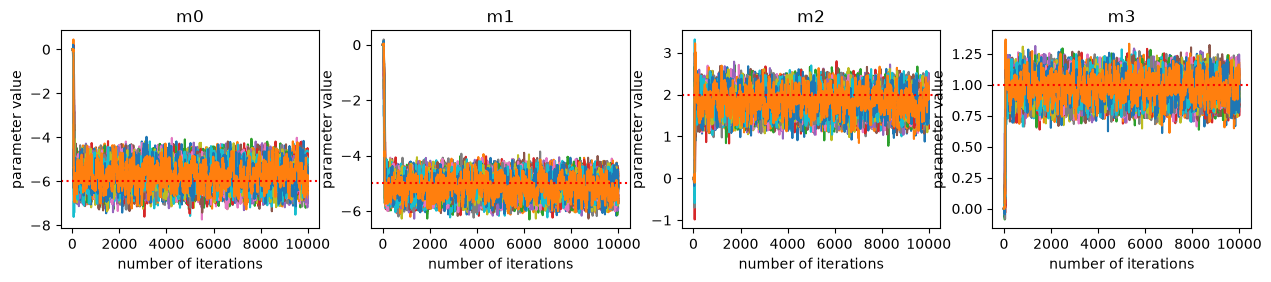

In [ ]:
def plot_trace():
    pc = az.plot_trace(az_idata)
    for i, var in enumerate(["m0", "m1", "m2", "m3"]):
        val = pc.viz["plot"][var]
        ax = val.item() if hasattr(val, 'item') else val
        ax.axhline(m_true[i], linestyle='dotted', color='red')
        ax.set_xlabel("number of iterations")
        ax.set_ylabel("parameter value")
    return pc
plot_trace()

Corner plots show the marginal and joint distributions of the parameters. The diagonal panels display each parameter's marginal posterior, while the off-diagonal panels reveal correlations between parameter pairs. They allow identifying problematic dependencies, highly correlated parameters can cause sampling difficulties and indicate potential identifiability issues.


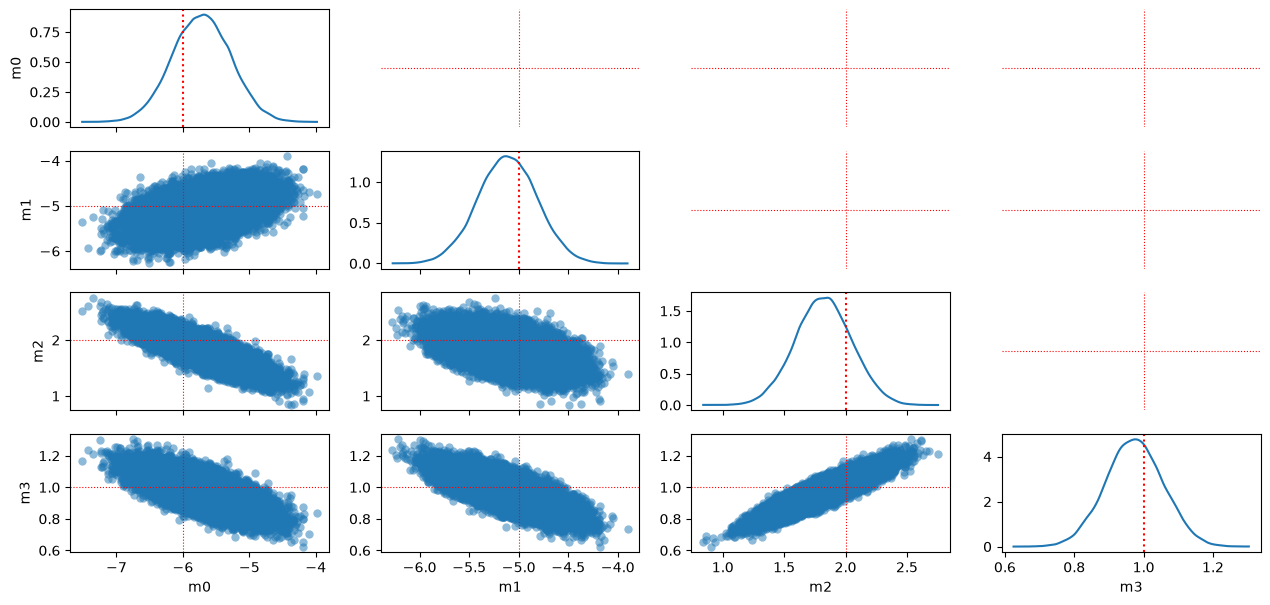

In [ ]:
def plot_corner():
    pc = az.plot_pair(
        az_idata.sel(draw=slice(300, None, 10)),
        marginal=True,
        marginal_kind="kde",
    )
    plot_da = pc.viz["plot"]
    for i, val_y in enumerate(m_true.tolist()):
        for j, val_x in enumerate(m_true.tolist()):
            val = plot_da.sel(row_index=i, col_index=j)
            ax = val.item() if hasattr(val, 'item') else val
            if ax is not None:
                if i == j:
                    ax.axvline(val_x, linestyle='dotted', color='red')
                else:
                    ax.axhline(val_y, linestyle='dotted', color='red', lw=0.8)
                    ax.axvline(val_x, linestyle='dotted', color='red', lw=0.8)
    return pc
plot_corner()

Posterior predictive plots compare data simulated from recovered model against the actual observed data. If the posterior distribution captures the data-generating process well, simulated data should look similar to observed data. This serves as a sanity check—systematic discrepancies revealing where a model fails to capture important features of the data, guiding model refinement.

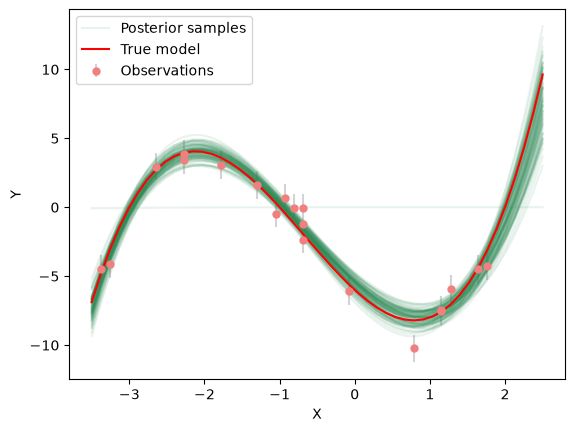

In [ ]:
def plot_posterior_predictive_synthetic():
    flat_samples = sampler.get_chain(discard=10, thin=1, flat=True)
    inds = np.random.randint(len(flat_samples), size=100)

    fig, ax = plt.subplots()
    ax.errorbar(x_obs, y_obs, yerr=sigma, fmt='.', color="lightcoral", ecolor='lightgrey', ms=10, label="Observations")

    G = jacobian(x)
    ax.plot(x, G.dot(flat_samples[0]), color="seagreen", label="Posterior samples", alpha=0.1)
    for m in flat_samples[inds]:
        ax.plot(x, G.dot(m), color="seagreen", alpha=0.1)

    ax.plot(x, jacobian(x).dot(m_true), color="red", label="True model")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    return ax
plot_posterior_predictive_synthetic()

The ensemble of polynomial coefficients found during Bayesian sampling correspond to curves that fit the data reasonably given the noise present. The spread of prediction curves at any point X gives uncertainty in the posterior prediction.

Next we consider a more complex regression problem involving real data. Here we will see that simple polynomial regression will be insufficient to capture the complexity of the data trends.

## Sea level data

Earth's sea level has undergone dramatic changes over the past 35,000 years. During the Last Glacial Maximum (~21,000 years ago), vast ice sheets locked up so much water that global sea level sat approximately 130 metres below present levels. As the climate warmed, these ice sheets melted, and sea level rose—but not at a constant rate.

[Lambeck et al. (2014)](https://www.pnas.org/doi/10.1073/pnas.1411762111) compiled ~1,000 sea level observations from "far-field" sites (locations distant from former ice margins, where the signal reflects global rather than local ice changes). Their reconstruction reveals a striking pattern: sea level remained relatively stable during the glacial maximum, then rose rapidly during deglaciation (~16.5 to 8.2 ka BP), before stabilising again through the late Holocene.

This history poses a natural question for data analysis: can such behaviour be captured with a simple mathematical model?

Below we begin by fitting polynomials to a portion of this sea level record. Polynomials are a natural starting point—they're flexible, well-understood, and easy to fit. But as will become evident, a single polynomial struggles to represent data with fundamentally different behaviours in different time periods. The residuals reveal systematic patterns that signal model inadequacy.

This failure motivates a more appropriate approach: change-point regression, where the relationship between time and sea level can shift at a transition point.

With CoFI, moving from polynomial fitting to change-point detection requires only modest code changes—letting us focus on the scientific insight rather than implementation details.

#### References

> Sea level and global ice volumes from the Last Glacial Maximum to the Holocene, K. Lambeck, H. Rouby, A. Purcell, Y. Sun, and M. Sambridge, 2014. Proc. Nat. Acad. Sci., 111, no. 43, 15296-15303, doi:10.1073/pnas.1411762111.

### Data

First, load the data and generate a figure of Eustatic Sea-Level in metres relative to present day over the past 20,000 years.

In [ ]:
from pathlib import Path as _Path
def data_path(filename):
    return _Path(__file__).resolve().parent.parent / "data" / filename

In [ ]:
from pathlib import Path as _Path2
save_figures = True
_fig_dir = _Path2(__file__).resolve().parent.parent / "figures" / "educator"
def save_fig(fig, name):
    if save_figures:
        fig.savefig(_fig_dir / f"{name}.png", dpi=150, bbox_inches='tight')

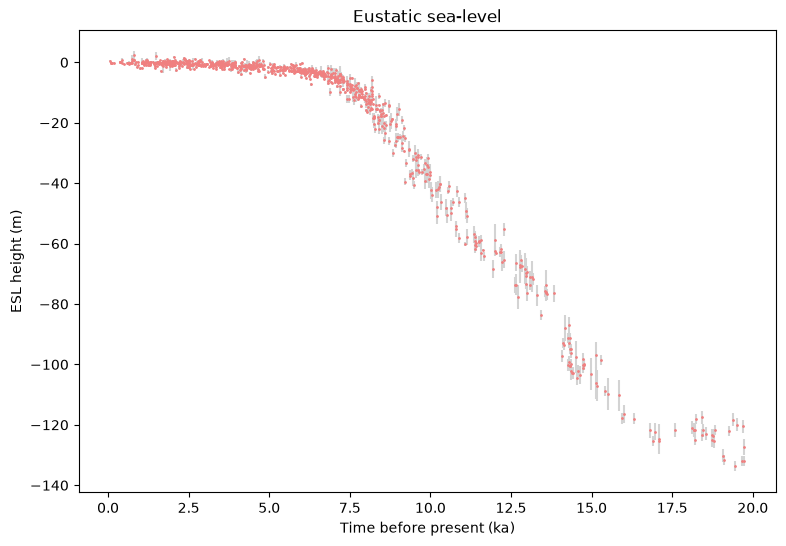

In [ ]:
# Load sea level data
# Columns: age (ka BP), sea level (m), 2σ age uncertainty, 2σ sea level uncertainty
raw_data = np.loadtxt(data_path("ESL-ff11-sorted.txt"), skiprows=1)
slvl_age = raw_data[:, 0]          # Age (ka BP)
slvl_y = raw_data[:, 1]            # Eustatic sea level (m)
slvl_sigma = raw_data[:, 3] / 2    # Convert 2σ to 1σ uncertainty

# Select data within time range of interest
max_age = 20.0  # ka BP
mask = slvl_age < max_age
slvl_age = slvl_age[mask]
slvl_y = slvl_y[mask]
slvl_sigma = slvl_sigma[mask]

def plot_slvl_data():
    fig, ax = plt.subplots(figsize=(9,6))
    ax.errorbar(slvl_age, slvl_y, yerr=slvl_sigma, fmt='.',color="lightcoral",ecolor='lightgrey',ms=2)
    ax.set_xlabel('Time before present (ka)')
    ax.set_ylabel('ESL height (m)')
    ax.set_title('Eustatic sea-level')
    return ax

plot_slvl_data()

### Fitting a Polynomial

CoFI was already set up to fit a polynomial using emcee. Rather than creating a new problem from scratch, the existing `BaseProblem` can be updated with what has changed:

- **Data** — sea level observations replace synthetic data
- **Data covariance** — heteroscedastic (each point has its own uncertainty)
- **Log-likelihood and log-prior** — must reference the new data and appropriate bounds

The generic `forward` and `jacobian` functions require no modification.

In [ ]:
# Heteroscedastic covariance — each observation has its own uncertainty
# Pre-compute inverse variance (diagonal of C_d^{-1}) once
_slvl_inv_var = 1.0 / slvl_sigma**2

def slvl_Cd_inv():
    return np.diag(_slvl_inv_var)

# Log-likelihood for sea level data (optimized for diagonal covariance)
def slvl_log_likelihood(model):
    y_pred = forward(model, slvl_age)
    residual = slvl_y - y_pred
    # For diagonal C_d^{-1}: r^T C_d^{-1} r = sum(r^2 / sigma^2)
    return -0.5 * np.sum(residual**2 * _slvl_inv_var)

# Prior bounds appropriate for sea level polynomial (cubic)
slvl_ndim = 4
slvl_m_lower = np.array([-100., -50., -5., -1.])
slvl_m_upper = np.array([100., 50., 5., 1.])

def slvl_log_prior(model): # Uniform prior in bounds without normalization constant
    for i in range(slvl_ndim):
        if model[i] < slvl_m_lower[i] or model[i] > slvl_m_upper[i]:
            return -np.inf
    return 0.0

Now perform Bayesian sampling of product of Likelihood and prior using ${\bf nwalkers}$ making ${\bf nsteps}$ each.

In [ ]:
# Update existing BaseProblem — reuse, don't rewrite
inv_problem.set_data(slvl_y)
inv_problem.set_forward(forward, args=(slvl_age,))
inv_problem.set_jacobian(jacobian(slvl_age, np.ones(slvl_ndim)))
inv_problem.set_data_covariance_inv(slvl_Cd_inv())
inv_problem.set_log_likelihood(slvl_log_likelihood)
inv_problem.set_log_prior(slvl_log_prior)
inv_problem.set_initial_model(np.ones(slvl_ndim))
inv_problem.set_model_shape(slvl_ndim)
inv_problem.set_data_misfit("squared error")

# First get MAP estimate via optimization
inv_options.set_solving_method("optimization")
inv_options.set_tool("scipy.optimize.minimize")
inv_options.hyper_params.clear()
inv_options.set_params(method="Nelder-Mead")

_inversion = Inversion(inv_problem, inv_options)
result_map = _inversion.run()
slvl_map = result_map.model
print(f"MAP estimate: {slvl_map}")

# Initialize walkers around MAP solution — switch back to sampling
slvl_walkers_start = slvl_map + 1e-4 * np.random.randn(nwalkers_emcee, slvl_ndim)
inv_options.set_solving_method("sampling")
inv_options.set_tool("emcee")
inv_options.hyper_params.clear()
inv_options.set_params(nwalkers=nwalkers_emcee, nsteps=nsteps, initial_state=slvl_walkers_start, progress=True)

# Run emcee
_inversion = Inversion(inv_problem, inv_options)
result_slvl = _inversion.run()

print("Sea level polynomial fit (emcee):")
_s = result_slvl.sampler
print(f"emcee: {_s.nwalkers} walkers × {_s.get_chain().shape[0]} steps, {slvl_ndim} params")
print(f"mean acceptance fraction: {_s.acceptance_fraction.mean():.3f}")

MAP estimate: [-1.39078749  1.16086033 -0.1601382  -0.01839843]


100%|██████████| 10000/10000 [00:08<00:00, 1207.70it/s]


Sea level polynomial fit (emcee):
emcee: 32 walkers × 10000 steps, 4 params
mean acceptance fraction: 0.595


In [ ]:
slvl_sampler = result_slvl.sampler
slvl_az_idata = az.from_emcee(slvl_sampler, var_names=["m0", "m1", "m2", "m3"])
slvl_az_idata.get("posterior")

<xarray.DataTree 'posterior'>
Group: /posterior
 Dimensions: (draw: 10000, chain: 32)
 Coordinates:
 * draw (draw) int64 80kB 0 1 2 3 4 5 6 ... 9994 9995 9996 9997 9998 9999
 * chain (chain) int64 256B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30 31
 Data variables:
 m0 (draw, chain) float64 3MB -1.391 -1.391 -1.391 ... -1.389 -1.423
 m1 (draw, chain) float64 3MB 1.161 1.161 1.161 ... 1.161 1.159 1.18
 m2 (draw, chain) float64 3MB -0.1603 -0.1601 -0.16 ... -0.1594 -0.1619
 m3 (draw, chain) float64 3MB -0.01849 -0.01804 ... -0.01847 -0.01838
 Attributes:
 created_at: 2026-07-13T01:28:59.950045+00:00
 creation_library: ArviZ
 creation_library_version: 1.2.0
 creation_library_language: Python
 inference_library: emcee
 inference_library_version: 3.1.6
 sample_dims: ['draw', 'chain'] xarray.DataTree 'posterior' Dimensions: draw : 10000 chain : 32 Coordinates: (2) draw (draw) int64 0 1 2 3 4 ... 9996 9997 9998 9999 array([ 0, 1, 2, ..., 9997, 9998, 9999], shape=(10000,)) chain (chain) int64 0 1 2 3 4 5 6 ... 26 27 28 29 30 31 array([ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,
 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]) Data variables: (4) m0 (draw, chain) float64 -1.391 -1.391 ... -1.389 -1.423 array([[-1.39067919, -1.39073159, -1.3907304 , ..., -1.39075507,
 -1.39085539, -1.3906505 ],
 [-1.39067919, -1.39071342, -1.3907304 , ..., -1.39077001,
 -1.39085539, -1.39064119],
 [-1.39067919, -1.39071293, -1.39063775, ..., -1.39078963,
 -1.39080228, -1.39064119],
 ...,
 [-1.39946832, -1.42155099, -1.3734782 , ..., -1.38637266,
 -1.37900216, -1.4124157 ],
 [-1.39778744, -1.42376697, -1.37323214, ..., -1.39062994,
 -1.38627179, -1.4124157 ],
 [-1.39775432, -1.42376697, -1.37323214, ..., -1.39129309,
 -1.38871792, -1.42279 ]], shape=(10000, 32)) m1 (draw, chain) float64 1.161 1.161 1.161 ... 1.159 1.18 array([[1.16096571, 1.16090897, 1.16097389, ..., 1.16084732, 1.1610573 ,
 1.16096291],
 [1.16096571, 1.1609282 , 1.16097389, ..., 1.16077071, 1.1610573 ,
 1.16096805],
 [1.16096571, 1.16092993, 1.16098273, ..., 1.16079376, 1.16101528,
 1.16096805],
 ...,
 [1.17249809, 1.18601611, 1.14861902, ..., 1.15743083, 1.15682613,
 1.17342892],
 [1.17487873, 1.18732488, 1.14868276, ..., 1.16004606, 1.15727499,
 1.17342892],
 [1.16884603, 1.18732488, 1.14868276, ..., 1.16089728, 1.1590517 ,
 1.17974584]], shape=(10000, 32)) m2 (draw, chain) float64 -0.1603 -0.1601 ... -0.1594 -0.1619 array([[-0.16027597, -0.16008577, -0.1600428 , ..., -0.1601285 ,
 -0.16023742, -0.1600624 ],
 [-0.16027597, -0.16008728, -0.1600428 , ..., -0.16018038,
 -0.16023742, -0.16005872],
 [-0.16027597, -0.16011442, -0.16015748, ..., -0.16016984,
 -0.16026114, -0.16005872],
 ...,
 [-0.1635286 , -0.16557425, -0.15693977, ..., -0.15812425,
 -0.15902852, -0.16183908],
 [-0.16418234, -0.16580376, -0.15695948, ..., -0.15873152,
 -0.15904734, -0.16183908],
 [-0.1623823 , -0.16580376, -0.15695948, ..., -0.15914918,
 -0.15936481, -0.16193867]], shape=(10000, 32)) m3 (draw, chain) float64 -0.01849 -0.01804 ... -0.01838 array([[-0.01849221, -0.01803634, -0.01833329, ..., -0.01833891,
 -0.01851433, -0.01833475],
 [-0.01849221, -0.01811326, -0.01833329, ..., -0.01834232,
 -0.01851433, -0.01836752],
 [-0.01849221, -0.01815632, -0.01834588, ..., -0.01836203,
 -0.01849266, -0.01836752],
 ...,
 [-0.01815306, -0.01808145, -0.01861048, ..., -0.01857183,
 -0.0185155 , -0.0183293 ],
 [-0.01809507, -0.01806871, -0.018613 , ..., -0.01853218,
 -0.01848088, -0.0183293 ],
 [-0.01820831, -0.01806871, -0.018613 , ..., -0.01849971,
 -0.01846728, -0.0183849 ]], shape=(10000, 32)) Attributes: (7) created_at : 2026-07-13T01:28:59.950045+00:00 creation_library : ArviZ creation_library_version : 1.2.0 creation_library_language : Python inference_library : emcee inference_library_version : 3.1.6 sample_dims : ['draw', 'chain']

#### Trace plot


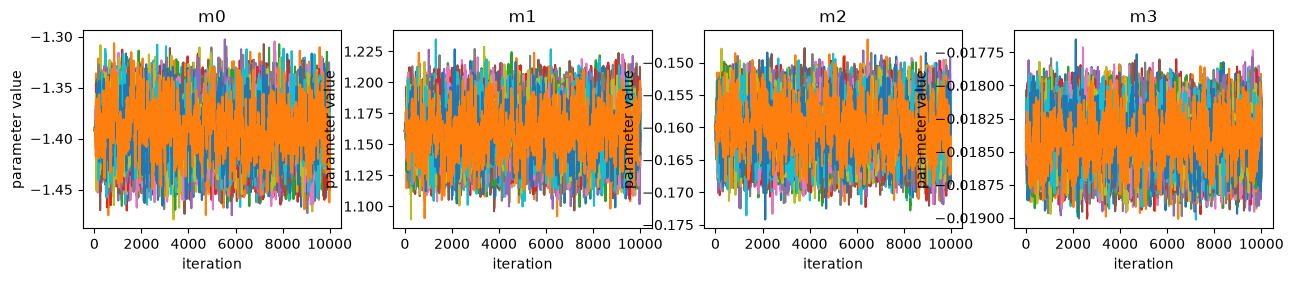

In [ ]:
def plot_slvl_trace():
    pc = az.plot_trace(slvl_az_idata)
    for var in ["m0", "m1", "m2", "m3"]:
        val = pc.viz["plot"][var]
        ax = val.item() if hasattr(val, 'item') else val
        ax.set_xlabel("iteration")
        ax.set_ylabel("parameter value")
    return pc
plot_slvl_trace()

#### Corner plot


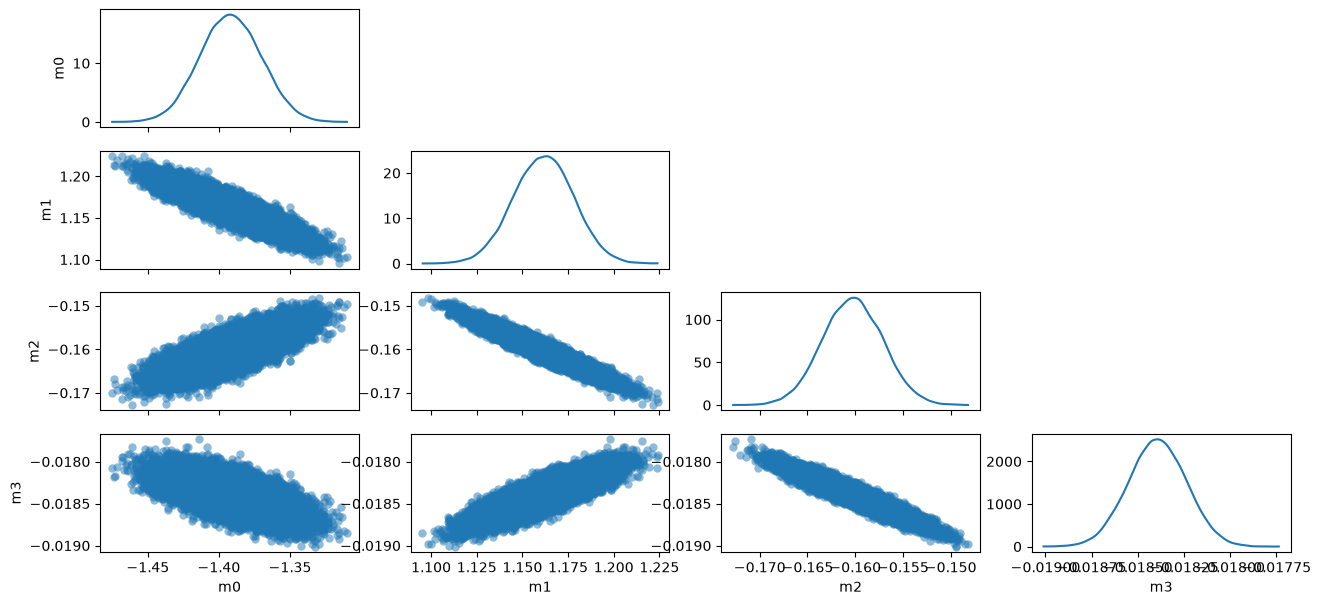

In [ ]:
def plot_slvl_corner():
    pc = az.plot_pair(
        slvl_az_idata.sel(draw=slice(300, None, 10)),
        marginal=True,
        marginal_kind="kde",
    )
    return pc
plot_slvl_corner()

This 3rd order polynomial has tightly constrained model coefficients.

#### Posterior predictive check

The posterior predictive check reveals that the model is overdetermined. Like for the synthetic example, a range of green curves should envelope the observations. More importantly, the fitted model cannot explain the early observations.

In [ ]:
def plot_posterior_predictive(sampler, x_obs, y_obs, sigma_obs, title=None, discard=10, label_fontsize=10, title_fontsize=10):
    """Plot posterior predictive samples against observations."""
    flat_samples = sampler.get_chain(discard=discard, thin=1, flat=True)
    inds = np.random.randint(len(flat_samples), size=100)
    x_plot = np.linspace(0, x_obs.max(), 200)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.errorbar(x_obs, y_obs, yerr=sigma_obs, fmt='.', color="lightcoral", ecolor='lightgrey', ms=4, label="Observations")

    for i, idx in enumerate(inds):
        m_sample = flat_samples[idx]
        lbl = "Posterior samples" if i == 0 else None
        ax.plot(x_plot, jacobian(x_plot, m_sample).dot(m_sample), color="seagreen", alpha=0.1, label=lbl)

    ax.set_xlabel("Time before present (ka)", fontsize=label_fontsize)
    ax.set_ylabel("ESL height (m)", fontsize=label_fontsize)
    if title:
        ax.set_title(title, fontsize=title_fontsize)
    ax.legend()
    return fig, ax


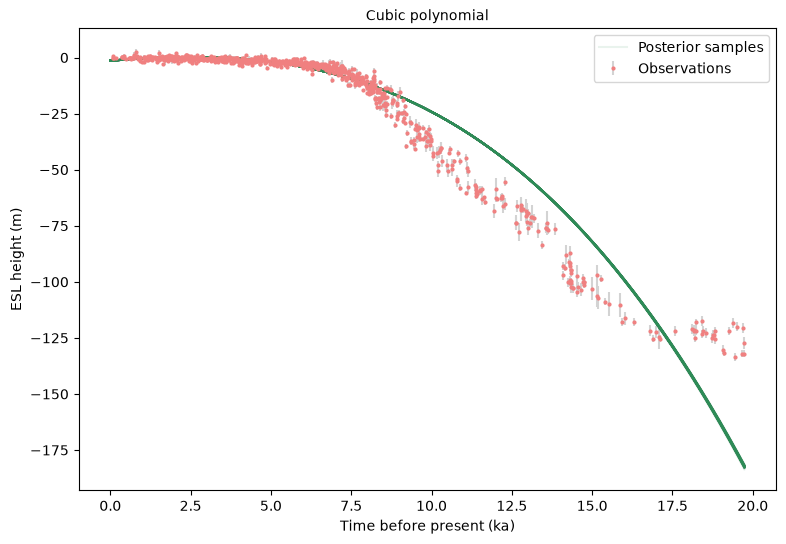

In [ ]:
plot_posterior_predictive(slvl_sampler, slvl_age, slvl_y, slvl_sigma, title="Cubic polynomial")

Unfortunately the model class of a 3rd order polynomial can not capture the complex structure in the observations. Look how poorly the green curve fits the data. More flexibility and model detail is required.

### Higher-order polynomial (degree 10)

A higher-order polynomial is now used as the model basis to see if it can better capture the sea level variations. Lets perform the Bayesian sampling with this new model basis.

In [ ]:
# Degree 10 polynomial (11 parameters)
slvl_ndim_10 = 11

# Pre-compute inverse variance once
_slvl_inv_var_10 = 1.0 / slvl_sigma**2

def slvl_Cd_inv_10():
    return np.diag(_slvl_inv_var_10)

# Log-likelihood optimized for diagonal covariance
def slvl_log_likelihood_10(model):
    y_pred = forward(model, slvl_age)
    residual = slvl_y - y_pred
    return -0.5 * np.sum(residual**2 * _slvl_inv_var_10)

# Wide uniform prior
slvl_m_lower_10 = -1e3 * np.ones(slvl_ndim_10)
slvl_m_upper_10 = 1e3 * np.ones(slvl_ndim_10)

def slvl_log_prior_10(model):
    for i in range(slvl_ndim_10):
        if model[i] < slvl_m_lower_10[i] or model[i] > slvl_m_upper_10[i]:
            return -np.inf
    return 0.0

In [ ]:
# Update existing BaseProblem for degree 10
inv_problem.set_data(slvl_y)
inv_problem.set_forward(forward, args=(slvl_age,))
inv_problem.set_jacobian(jacobian(slvl_age, np.ones(slvl_ndim_10)))
inv_problem.set_data_covariance_inv(slvl_Cd_inv_10())
inv_problem.set_log_likelihood(slvl_log_likelihood_10)
inv_problem.set_log_prior(slvl_log_prior_10)
inv_problem.set_initial_model(np.zeros(slvl_ndim_10))
inv_problem.set_model_shape(slvl_ndim_10)
inv_problem.set_data_misfit("squared error")

# MAP estimate first
inv_options.set_solving_method("optimization")
inv_options.set_tool("scipy.optimize.minimize")
inv_options.hyper_params.clear()
inv_options.set_params(method="Nelder-Mead")

_inversion = Inversion(inv_problem, inv_options)
result_map_10 = _inversion.run()
slvl_map_10 = result_map_10.model
print(f"MAP estimate (degree 10): {slvl_map_10}")

# Initialize walkers around MAP — switch back to sampling
slvl_walkers_start_10 = slvl_map_10 + 1e-4 * np.random.randn(nwalkers_emcee, slvl_ndim_10)
inv_options.set_solving_method("sampling")
inv_options.set_tool("emcee")
inv_options.hyper_params.clear()
inv_options.set_params(nwalkers=nwalkers_emcee, nsteps=nsteps, initial_state=slvl_walkers_start_10, progress=True)

_inversion = Inversion(inv_problem, inv_options)
result_slvl_10 = _inversion.run()

_s = result_slvl_10.sampler
print(f"emcee: {_s.nwalkers} walkers × {_s.get_chain().shape[0]} steps, {slvl_ndim_10} params")
print(f"mean acceptance fraction: {_s.acceptance_fraction.mean():.3f}")

MAP estimate (degree 10): [ 1.42770058e-01 -1.20762929e-01 -6.51511009e-02 -6.66956180e-03
  4.41938765e-03  7.51622269e-04 -2.65569528e-04 -8.42832169e-06
  4.20670785e-06 -2.59715915e-07  4.87575109e-09]


100%|██████████| 10000/10000 [00:28<00:00, 348.31it/s]


emcee: 32 walkers × 10000 steps, 11 params
mean acceptance fraction: 0.405


In [ ]:
_labels_10 = [f"m{i}" for i in range(11)]
az_idata_10 = az.from_emcee(result_slvl_10.sampler, var_names=_labels_10)

#### Trace plots (degree 10)

Inspect the trace plots to assess convergence and choose an appropriate burn-in.


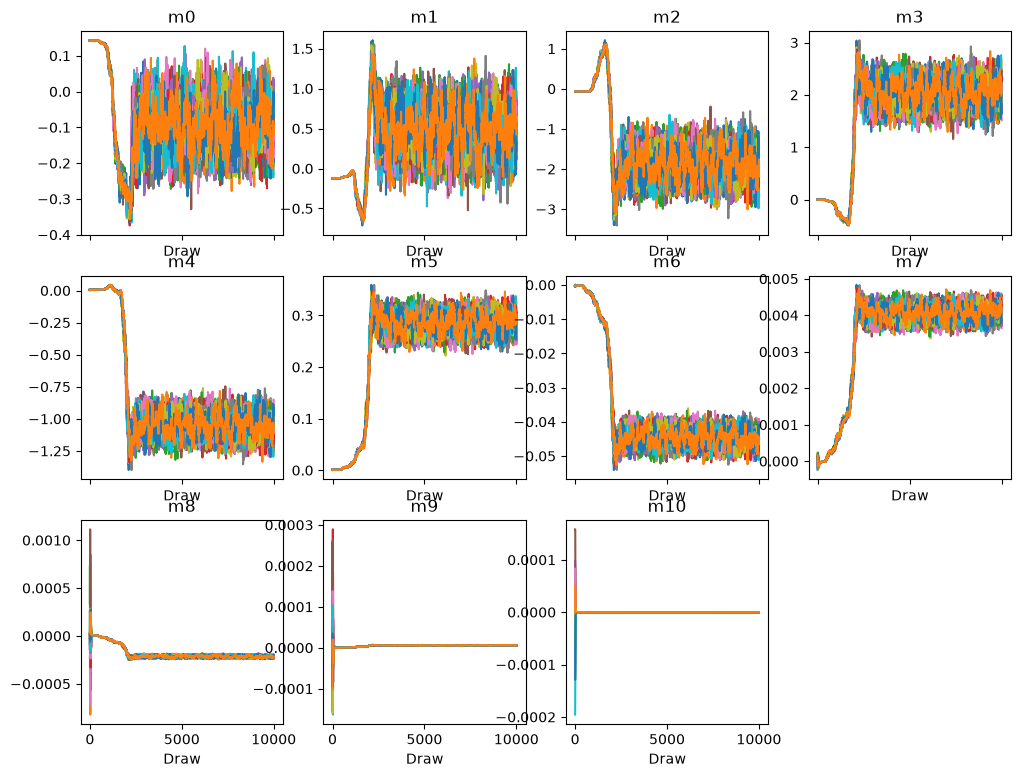

In [ ]:
def plot_trace_10():
    pc = az.plot_trace(az_idata_10, figure_kwargs={"figsize": (12, 9)})
    return pc
plot_trace_10()

The trace plot shows that it takes about 2500 chain steps for convergence, and so we set the burnin value to this number and discard 2500 steps in the analysis below.

#### Corner plot (degree 10)

Pairwise marginal distributions for all 11 parameters. Adjust the `burn_in_10` value
based on the trace plots above, then rerun to see the post-burn-in posteriors.


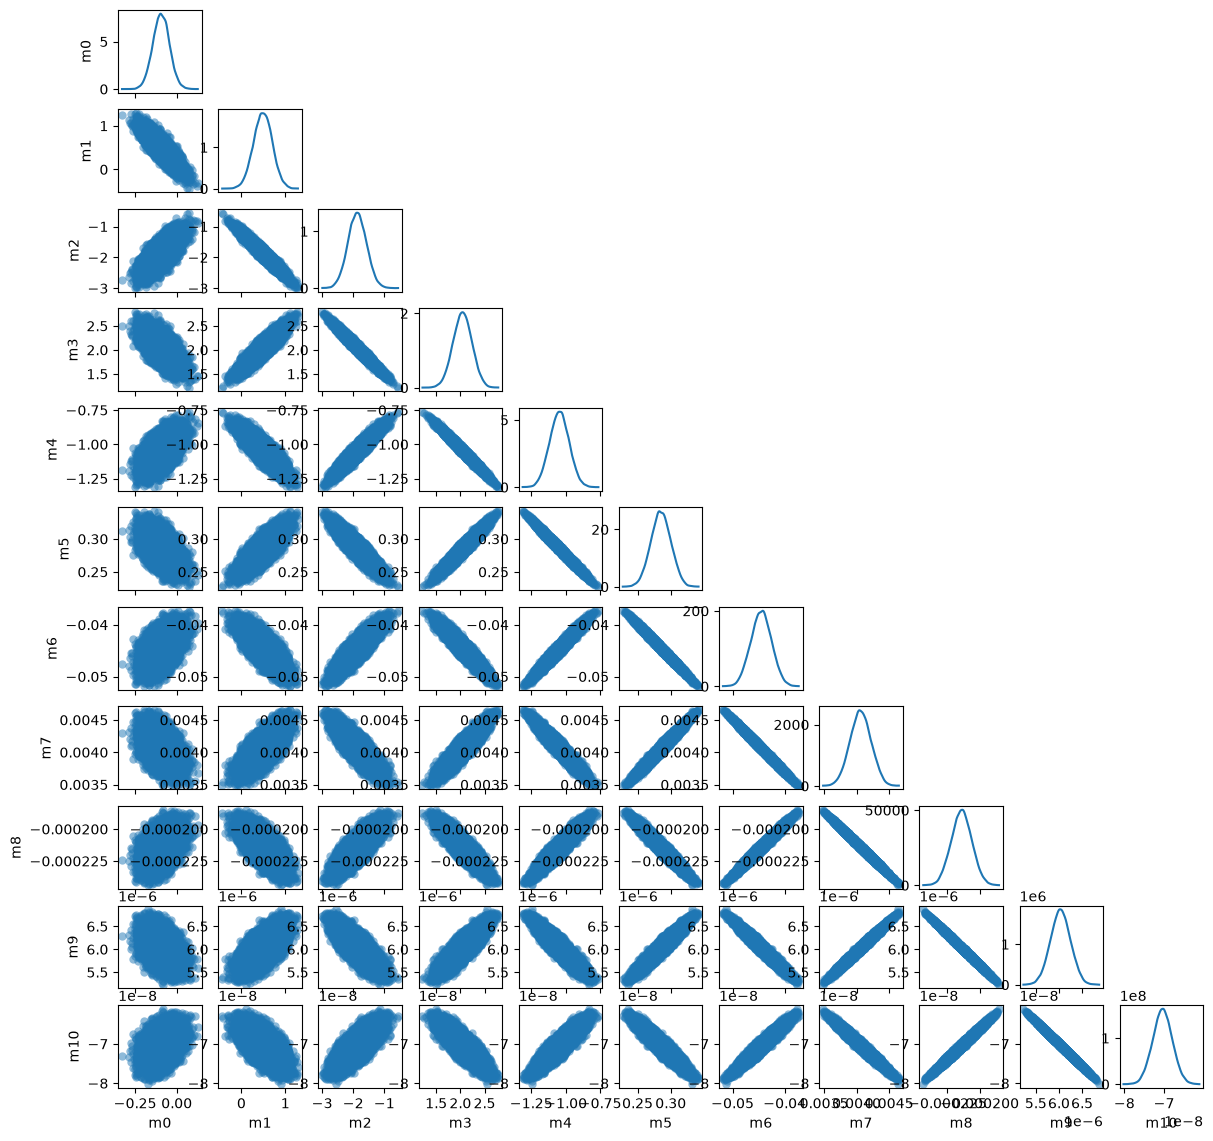

In [ ]:
burn_in_10 = 2500
def plot_corner_10():
    az.rcParams['plot.max_subplots'] = 150
    pc = az.plot_pair(
        az_idata_10.sel(draw=slice(burn_in_10, None, 10)),
        marginal=True,
        marginal_kind="kde",
        figure_kwargs={"figsize": (14, 14)},
    )
    return pc
plot_corner_10()

#### Posterior predictive check

Lets have a look at the predicted curves from the sampled ensemble to see if they are any better.

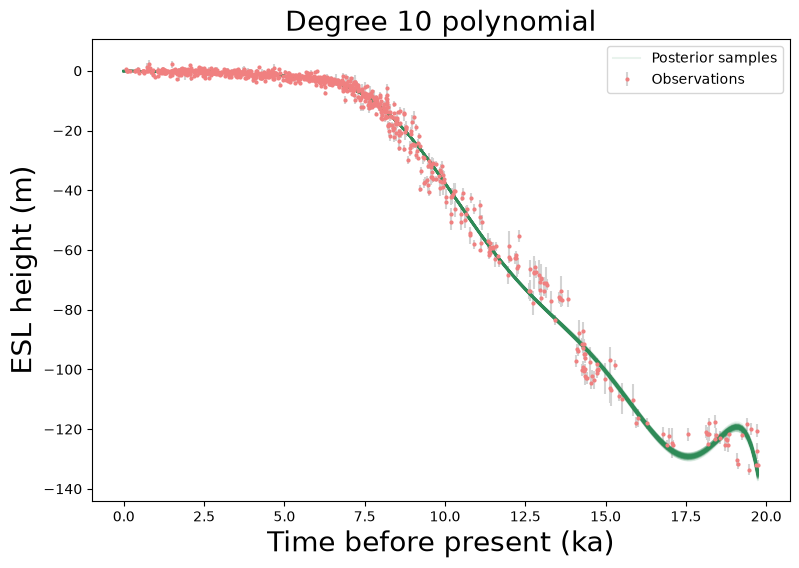

In [ ]:
slvl_sampler_10 = result_slvl_10.sampler
fig, _ = plot_posterior_predictive(slvl_sampler_10, slvl_age, slvl_y, slvl_sigma, title="Degree 10 polynomial", discard=burn_in_10, label_fontsize=20, title_fontsize=20)
save_fig(fig, 'Sea_level_polyfit_10')
plt.show()

After roughly 2500 burn-in steps, the chains reach a stationary phase and the posterior is unimodal. We conclude here that a degree-10 polynomial can fit the data, but it's a global basis is prone to oscillation/overfitting at the ends of the data window. This motivates in the next section where we develop a partition model that uses the data to capture the time points where the character of sea level change varies in time.

### Partition model
We now use a partition representation of the sea level curve. In this case the curve is represented by a piecewise set of linear segments over time. The unknowns are the heights and positions of a set of (x,y) points and linear polynomials are drawn between them. This is illustrated by the following figure

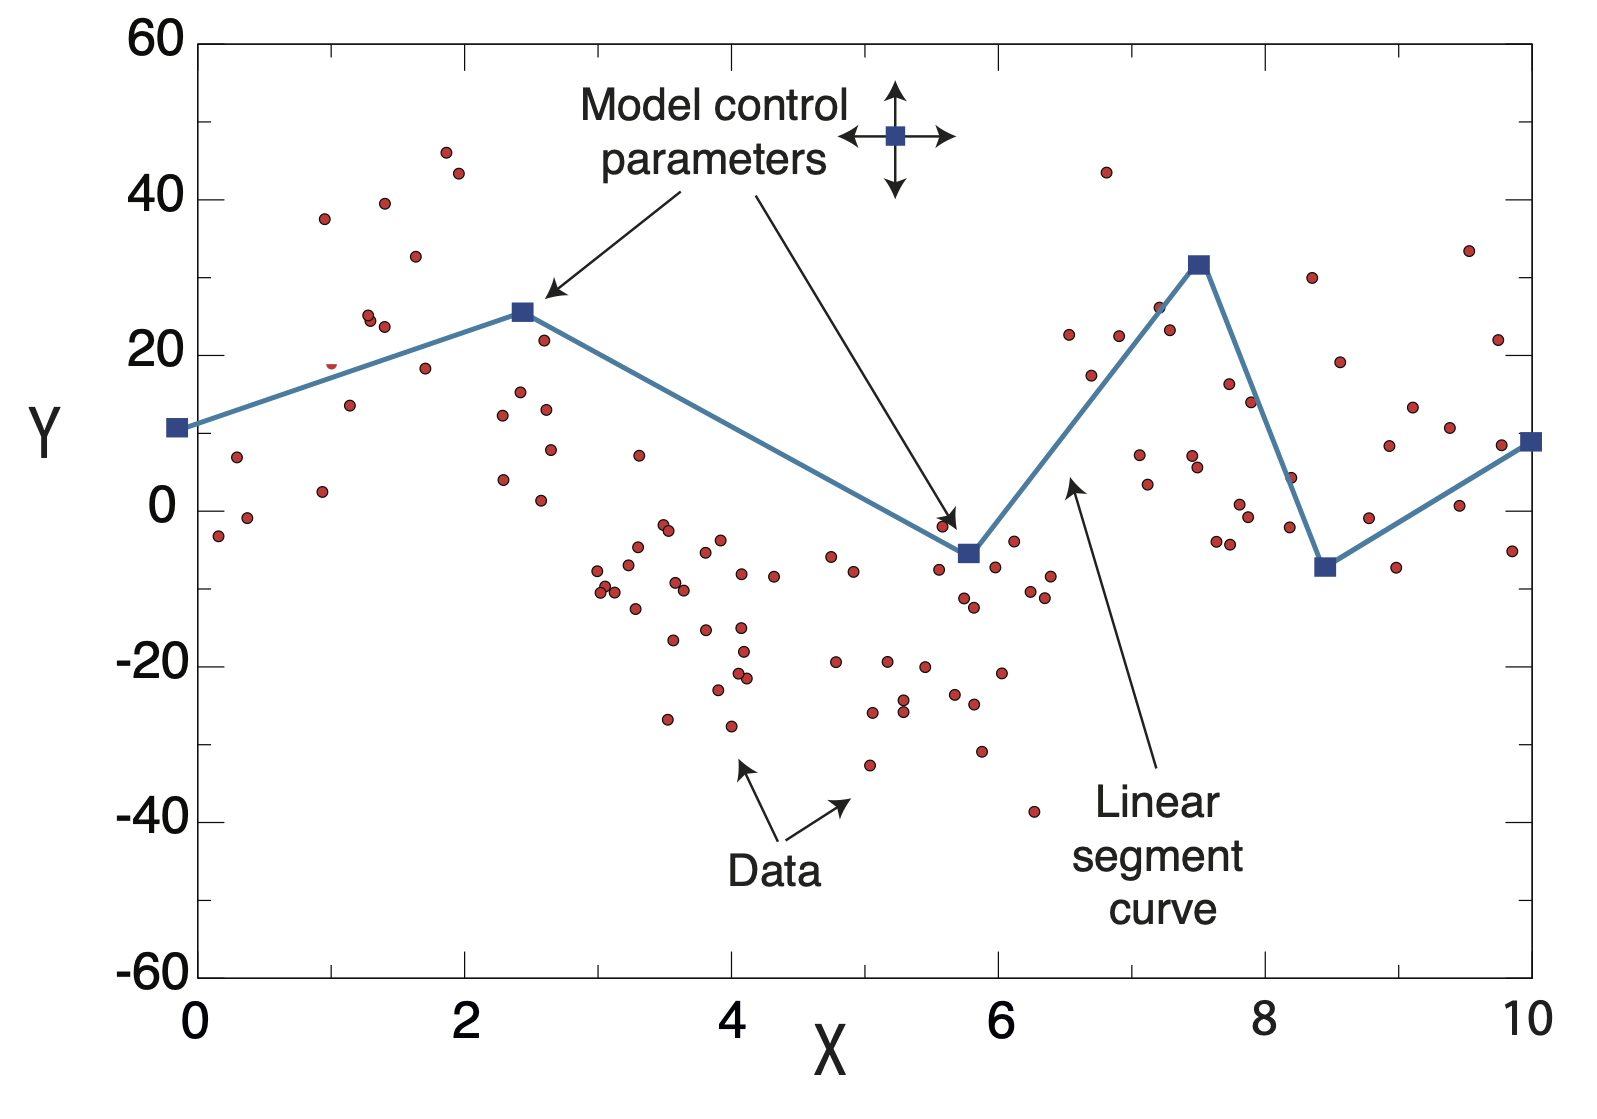

Here the blue lines represent the piecewise linear segment model for a particular curve with five partitions [Figure from Lambeck et al. (2013)]. For a model with $n$ partitions there are $(n+1)$ heights (y) and $(n-1)$ interface locations (x) that are treated as unknown. In a trans-D set up $n$ is also unknown and varies during the sampling.

To constrain the trans-dimensional partition model, a set of noisy height values $h_i (i=0,\dots,N)$ is available, measured at known times $t_i (i=0,\dots,N)$.

The height measurements are assumed to have independent Gaussian random noise, $\cal N(0,\Sigma)$, with $(\Sigma)_{ij} = \delta_{ij}/\sigma_i^2$, where the variance of the noise on each datum, $\sigma_i^2 (i=1,\dots,N)$, differs between observations and is given.

A reference model consisting of linear segments is imported and plotted on top of the data.

In [ ]:
from pathlib import Path as _Path
_img = (_Path(__file__).resolve().parent.parent / "figures" / "educator" / "partition_modelling_setup.png").read_bytes()
img = mo.image(src=_img)

mo.md(f"""
### Partition model
We now use a partition representation of the sea level curve. In this case the curve is represented by a piecewise set of linear segments over time. The unknowns are the heights and positions of a set of (x,y) points and linear polynomials are drawn between them. This is illustrated by the following figure

{img}

Here the blue lines represent the piecewise linear segment model for a particular curve with five partitions [Figure from Lambeck et al. (2013)]. For a model with $n$ partitions there are $(n+1)$ heights (y) and $(n-1)$ interface locations (x) that are treated as unknown. In a trans-D set up $n$ is also unknown and varies during the sampling.

To constrain the trans-dimensional partition model, a set of noisy height values $h_i (i=0,\\dots,N)$ is available, measured at known times $t_i (i=0,\\dots,N)$.

The height measurements are assumed to have independent Gaussian random noise, $\\cal N(0,\\Sigma)$, with $(\\Sigma)_{{ij}} = \\delta_{{ij}}/\\sigma_i^2$, where the variance of the noise on each datum, $\\sigma_i^2 (i=1,\\dots,N)$, differs between observations and is given.

A reference model consisting of linear segments is imported and plotted on top of the data.

""")

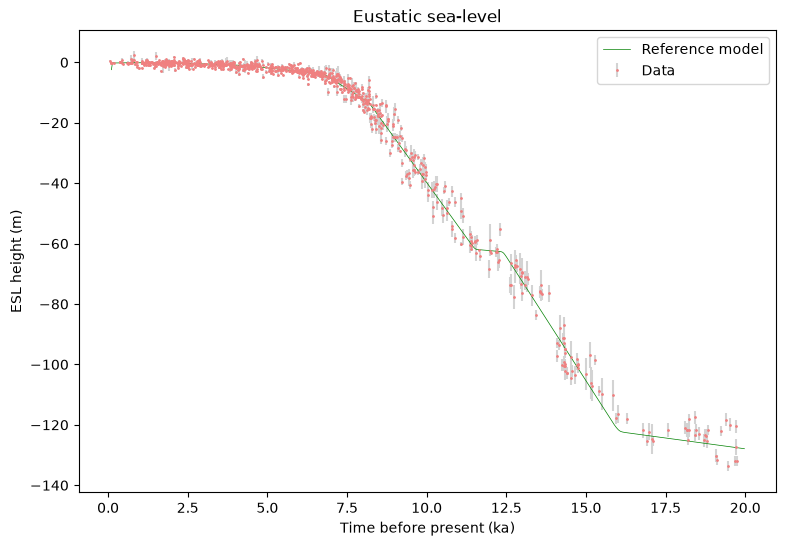

In [ ]:
# Load Reference model for plotting
slvl_ref_data = np.loadtxt(data_path("ESL-f11_yonly.txt"))
slvl_ref_x = slvl_ref_data[:, 0]  # Age (ka BP)
slvl_ref_y = slvl_ref_data[:, 1]  # ESL height (m)

# Select data within time range of interest
ref_mask = slvl_ref_x < max_age
slvl_ref_x = slvl_ref_x[ref_mask]
slvl_ref_y = slvl_ref_y[ref_mask]

def plot_slvl_with_reference():
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.errorbar(slvl_age, slvl_y, yerr=slvl_sigma, fmt='.', color="lightcoral", ecolor='lightgrey', ms=2, label="Data")
    ax.plot(slvl_ref_x, slvl_ref_y, color="green", lw=0.5, label="Reference model")
    ax.set_xlabel('Time before present (ka)')
    ax.set_ylabel('ESL height (m)')
    ax.set_title('Eustatic sea-level')
    ax.legend()
    return ax

plot_slvl_with_reference()

### Trans-D Bayesian sampling

In this case, an extra level sophistication is allowed by not only solving for the linear segment parameters $(x_i, y_i)$ in each partition but also the number of partitions $n$. This creates a variably dimensioned sampling problem which can be addressed with Bayes' theorem. In this case we have

$$p(\mathbf{m}, n|\mathbf{d}) = K p(\mathbf{d}|\mathbf{m}, n)p(\mathbf{m}|n)p(n)$$

where $p(\mathbf{d}|\mathbf{m}, n)$ is the Likelihood function of a given $n$ partitioned linear segment model; $p(\mathbf{m}|n)$ is the prior for the model coefficients given $n$; $p(n)$ is the prior over $n$, and $K$ is some constant. In contrast to the earlier cases, the model vector ${\bf m}$ now has dimension $2n$, where $n$ is also an unknown.  As before the ${a ~posteriori}$ distribution $p(\mathbf{m}, n|\mathbf{d})$ gives the probability density of (variably dimensioned) models supported by the data. The goal is to draw random samples from $p(\mathbf{m}, n|\mathbf{d})$ over the variably dimensioned model space and make inferences from the resulting ensemble of model parameters.

This example makes use of a package known as *BayesBay* which implements the reversible jump MCMC algorithm of [Green (1992)](https://www.jstor.org/stable/2337340?seq=1) to sample the posterior distribution. (For more details see the [bayesbay](https://bayes-bay.readthedocs.io/en/latest/index.html) documentation).

### Likelihood

Since data errors follow a Gaussian in this example, the Likelihood function $p({\mathbf d}_{obs}| {\mathbf m})$ can be defined as before.

$$
p({\mathbf d}_{obs} | {\mathbf m}) \propto \exp \left\{- \frac{1}{2} ({\mathbf d}_{obs}-{\mathbf d}_{pred}({\mathbf m}))^T C_D^{-1} ({\mathbf d}_{obs}-{\mathbf d}_{pred}({\mathbf m})) \right\}
$$

where ${\mathbf d}_{obs}$ represents the observed sea-level heights and ${\mathbf d}_{pred}({\mathbf m})$ are those predicted by the partition model unknowns $({\mathbf m})$, where

$$
{\mathbf m} = \left( n, y_1,y_2,\dots,y_{n+1}; x_1, x_2,\dots, x_{n-1} \right)^T
$$

The Likelihood is defined as the probability of observing the data actually observed, given a model. In practice, only the log of the Likelihood needs to be evaluated, $\log p({\mathbf d}_{obs} | {\mathbf m})$.

This requires the inverse data covariance matrix describing the statistics of the noise in the data, $C_D^{-1}$. For this problem the data errors are independent with identical standard deviation in noise for each datum. Hence $C_D^{-1} = \frac{1}{\sigma^2}I$ where $\sigma=1$.

### Prior

Trans-D Bayesian sampling requires a prior probability density function for all unknowns.
For a given number of partitions, $n$, a uniform prior is used for both sea-level heights, y, and partition locations, x, within specified bounds

$$
\begin{align}
p({\mathbf m}) &= \frac{1}{V},\quad  l_i \le m_i \le u_i, \quad (i=1,\dots,2n)\\
         &= 0, \quad \text{otherwise},
\end{align}
$$

where $l_i$ and $u_i$ are lower and upper bounds on the $i$th unknown, and $V$ is a normalization constant, $V = \prod_{i=1}^{2n} (u_i-l_i)$. A uniform prior over the number of partitions $1\le n \le N_{max}$ is also used.

### Define partition model

To implement the partition model in BayesBay, the following must be defined:

1. **Height parameters** — The sea level values at each control point
2. **Position parameters** — The time locations of interior control points (the endpoints are fixed)

Uniform priors are used for all parameters. The heights are bounded by the observed data range (with some margin), while positions are constrained to lie within the time window.

BayesBay's `Voronoi1D` discretization handles the trans-dimensional aspect: the number of interior control points varies during sampling, with the algorithm proposing birth (add point), death (remove point), and move operations.

#### Height priors

Three types of height parameters are defined:
- `y_start`: The sea level at the earliest time (fixed position)
- `y_end`: The sea level at the most recent time (fixed position)
- `y_inner`: Heights at interior control points (variable number and positions)

In [ ]:
# height variables y
y_range = slvl_y.max() - slvl_y.min()
y_start = UniformPrior(
    "y_start", vmin=slvl_y[0] - 5, vmax=slvl_y[0] + 5, perturb_std=0.5
)
y_end = UniformPrior("y_end", vmin=slvl_y[-1] - 5, vmax=slvl_y[-1] + 5, perturb_std=0.5)

y_inner = UniformPrior(
    "y_inner", vmin=slvl_y.min() - 5, vmax=slvl_y.max() + 5, perturb_std=y_range / 20
)

#### Parameterization

The parameterization combines two parameter spaces:

1. **Inner space** (`Voronoi1D`): Handles the variable number of interior control points. Each point has a position (time) and a height (sea level). The number of points can range from 1 to 15.

2. **Outer space** (`ParameterSpace`): Contains the fixed endpoint heights (`y_start` and `y_end`).

This separation allows BayesBay to efficiently propose trans-dimensional moves on the interior points while keeping the endpoints fixed.

In [ ]:
# using the 1D Voronoi setup to produce an interface parameterization with height variables within each
pspace_inner = Voronoi1D(
    name="pspace_inner",
    vmin=0,
    vmax=max_age,
    perturb_std=max_age / 20,
    n_dimensions=None,
    n_dimensions_min=1,
    n_dimensions_max=15,
    parameters=[y_inner],
)
pspace_outer = ParameterSpace(
    name="pspace_outer",
    n_dimensions=1,
    parameters=[y_start, y_end],
)
parameterization = Parameterization([pspace_inner, pspace_outer])

#### Forward model

The forward model for the partition representation computes predicted sea levels by linear interpolation between control points. Given the current state (positions and heights of all control points), it:

1. Constructs the full set of control points by combining endpoints with interior points
2. For each data point, identifies which segment it falls within
3. Linearly interpolates the sea level value

This piecewise-linear model can capture abrupt changes in sea level rise rate—something polynomial models struggle with.

In [ ]:
def forward_pm(state):
    global slvl_age

    # Control points at coordinates x and y
    x = np.concatenate(
        ([slvl_age[0]], state["pspace_inner"]["discretization"], [slvl_age[-1]])
    )
    y = np.concatenate(
        (
            state["pspace_outer"]["y_start"],
            state["pspace_inner"]["y_inner"],
            state["pspace_outer"]["y_end"],
        )
    )

    y_pred = np.zeros(slvl_age.size)
    for i in range(x.size - 1):
        # ith and (i+1)th control points
        x1, y1 = x[i], y[i]
        x2, y2 = x[i + 1], y[i + 1]

        dx = x2 - x1
        dy = y2 - y1

        # Get data between x2 and x1
        idata = np.flatnonzero((slvl_age >= x1) & (slvl_age < x2))
        dx_data = slvl_age[idata] - x1
        y_pred[idata] = y1 + dy / dx * dx_data

    # Handle last point
    y_pred[-1] = y[-1]
    return y_pred


target = Target("d_obs", slvl_y, covariance_mat_inv=1 / slvl_sigma**2)

log_likelihood_pm = LogLikelihood(targets=target, fwd_functions=forward_pm)

#### Running the trans-dimensional inversion

With CoFI, switching from emcee to BayesBay requires only updating the `InversionOptions`—the same pattern used throughout this tutorial. BayesBay handles the trans-dimensional MCMC internally, proposing:

- **Birth moves**: Add a new control point
- **Death moves**: Remove an existing control point
- **Perturbation moves**: Adjust positions or heights of existing points

The algorithm automatically balances model complexity against data fit, guided by the prior on the number of partitions.

In [ ]:
# initialize walkers from prior
n_chains_bayesbay = 4
walkers_start_bayesbay = []
for j in range(n_chains_bayesbay):
    walkers_start_bayesbay.append(parameterization.initialize())

# run the sampling — same pattern as before, just different tool
inv_options.set_solving_method("sampling")
inv_options.set_tool("bayesbay")
inv_options.hyper_params.clear()
inv_options.set_params(
    log_like_ratio_func=log_likelihood_pm,
    perturbation_funcs=parameterization.perturbation_funcs,
    walkers_starting_states=walkers_start_bayesbay,
    n_chains=n_chains_bayesbay,
    n_iterations=100_000,
    burnin_iterations=25_000,
    save_every=100,
    verbose=False,
)
_inversion = Inversion(inv_problem, inv_options)
result_bayesbay = _inversion.run()
results = result_bayesbay.models
y_pred = np.array(results["d_obs.dpred"])

percentiles = 10, 90
statistics = {
    "mean": np.mean(y_pred, axis=0),
    "median": np.median(y_pred, axis=0),
    "percentiles": np.percentile(y_pred, percentiles, axis=0),
}

#### Plotting Results

CoFI creates a result object from bayesbay that contains two piece sof information

1. **Ensemble of sea level curves** The median prediction of sea-level from the ensemble of solutions with uncertainty bounds shows how well the partition model captures the data.

2. **Posterior on number of partitions**  Describes the position ensemble of the number of partitions.

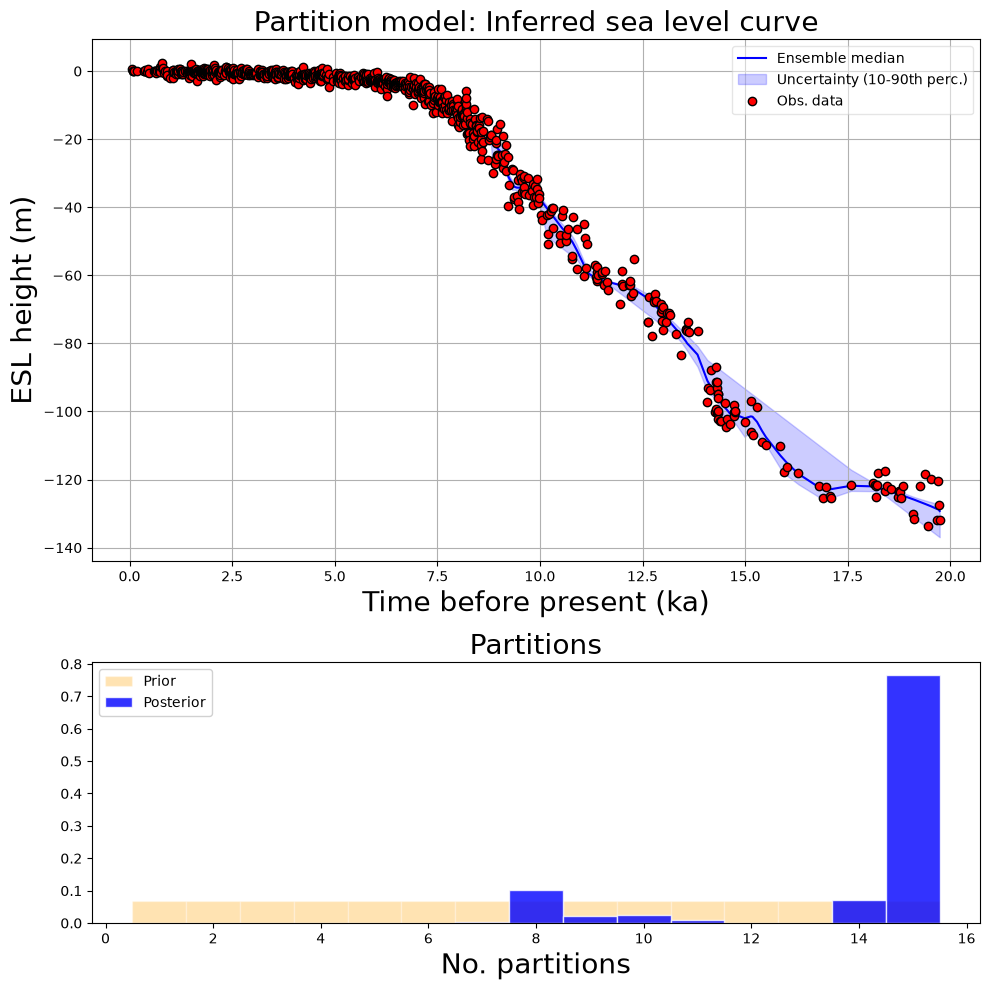

In [ ]:
# Plotting

_fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

ax1 = plt.subplot(gs[0, :])  # First row, spans all columns
ax2 = plt.subplot(gs[1, :])  # Second row, first column

ax1.plot(slvl_age, statistics["median"], "b", label="Ensemble median")
ax1.fill_between(
    slvl_age,
    *statistics["percentiles"],
    color="b",
    alpha=0.2,
    label="Uncertainty (%s-%sth perc.)" % (percentiles),
)
ax1.plot(slvl_age, slvl_y, "ro", markeredgecolor="k", label="Obs. data")
ax1.set_xlabel("Time before present (ka)", fontsize=20)
ax1.set_ylabel("ESL height (m)", fontsize=20)
ax1.legend(framealpha=0.5)
ax1.grid()
ax1.set_title("Partition model: Inferred sea level curve", fontsize=20)


ndim_min, ndim_max = pspace_inner._n_dimensions_min, pspace_inner._n_dimensions_max
ax2.hist(
    np.arange(ndim_min, ndim_max + 1),
    bins=np.arange(ndim_min - 0.5, ndim_max + 1.5),
    alpha=0.3,
    density=True,
    color="orange",
    ec="w",
    label="Prior",
)
ax2.set_xlabel("No. partitions", fontsize=20)
ax2.hist(
    results["pspace_inner.n_dimensions"],
    bins=np.arange(ndim_min - 0.5, ndim_max + 1.5),
    color="b",
    alpha=0.8,
    density=True,
    ec="w",
    label="Posterior",
)
ax2.legend(framealpha=0)
ax2.set_title("Partitions", fontsize=20)

ax2.legend(framealpha=0.9)
plt.tight_layout()
save_fig(_fig, 'Sea_level_polyfit_TransD_mean')
plt.show()

In the figures we see

1. **Ensemble of sea level curves** (top panel): The piecewise-linear model can represent abrupt changes in sea level rise rate. and fits the data well.

2. **Posterior on number of partitions** (bottom panel): Comparing the posterior (blue) to the prior (orange) reveals whether the data inform the model complexity. A posterior concentrated at fewer partitions than the prior maximum suggests the data don't require high complexity—the algorithm naturally favours simpler models that adequately explain the observations.

This automatic complexity selection is a key advantage of trans-dimensional inference: the number of change points does not need to be manually chosen.

## Conclusion

This tutorial demonstrated how CoFI enables rapid exploration of increasingly sophisticated inference techniques:

1. **Polynomial fitting** — Starting with simple linear least squares, then moving to iterative optimization, and finally Bayesian sampling with emcee. Each transition required only minor code changes.

2. **Model evaluation** — Posterior predictive checks revealed that polynomials—even high-order ones—struggle to capture the sea level data's piecewise behaviour. Systematic residual patterns signalled model inadequacy.

3. **Trans-dimensional inference** — Motivated by the data, a partition model with BayesBay was adopted. The trans-dimensional approach automatically determines appropriate model complexity, avoiding manual selection of the number of change points.

### Key takeaways

- **Unified interface**: CoFI's consistent API (`BaseProblem`, `InversionOptions`, `Inversion`) means switching between methods—matrix solvers, optimizers, samplers—requires only updating configuration, not rewriting code.

- **Reusable objects**: Throughout this tutorial, the same `inv_problem` and `inv_options` objects were reused, progressively updating them as the analysis evolved. This mirrors authentic scientific workflows where models are iteratively refined.

- **Focus on science**: By handling implementation details, CoFI lets learners concentrate on the scientific questions: *Which model best describes my data? How certain are my conclusions? Is my model complex enough—or too complex?*

These capabilities make CoFI particularly valuable for education, where the goal is conceptual understanding without the distraction of focusing on coding algorithms, data IO and plotting.

---

*Note: On Python 3.14+, you may see a harmless warning about "leaked semaphore objects" on shutdown. This is a known issue with the loky parallel processing library used by BayesBay and does not affect results.*

In [ ]:
import sys
import importlib.metadata
from datetime import datetime

# Packages explicitly imported in this notebook
_packages = [
    "numpy",
    "scipy",
    "matplotlib",
    "arviz",
    "emcee",
    "bayesbay",
    "cofi",
    "marimo",
]

_env_info = [{"Package": "Python", "Version": sys.version.split()[0]}]
for pkg in _packages:
    try:
        ver = importlib.metadata.version(pkg)
        _env_info.append({"Package": pkg, "Version": ver})
    except importlib.metadata.PackageNotFoundError:
        pass

mo.vstack([
    mo.md(f"**Environment** — {datetime.now().strftime('%Y-%m-%d %H:%M')}"),
    mo.ui.table(_env_info, selection=None, page_size=len(_env_info))
])

Environment — 2026-07-13 11:29 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"Package\":\"Python\",\"Version\":\"3.14.3\"},{\"Package\":\"numpy\",\"Version\":\"2.5.1\"},{\"Package\":\"scipy\",\"Version\":\"1.18.0\"},{\"Package\":\"matplotlib\",\"Version\":\"3.11.0\"},{\"Package\":\"arviz\",\"Version\":\"1.2.0\"},{\"Package\":\"emcee\",\"Version\":\"3.1.6\"},{\"Package\":\"bayesbay\",\"Version\":\"0.3.12\"},{\"Package\":\"cofi\",\"Version\":\"0.2.12\"},{\"Package\":\"marimo\",\"Version\":\"0.23.14\"}]"' data-total-rows='9' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='9' data-show-filters='false' data-show-download='true' data-show-search='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-hidden-columns='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>